In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import HDBSCAN
from sklearn.ensemble import IsolationForest

plt.style.use("ggplot")

In [2]:
df = pd.read_excel("data-domain-d.xlsx")

df.head()

,kode_prov,provinsi,kode_kab,kabupaten_kota,kemiskinan_persen,air_bersih_persen,jumlah_faskes
0,52,Nusa Tenggara Barat,5201,Lombok Barat,11.90,96.29,50
1,52,Nusa Tenggara Barat,5202,Lombok Tengah,10.68,96.29,61
2,52,Nusa Tenggara Barat,5203,Lombok Timur,13.53,96.29,83
3,52,Nusa Tenggara Barat,5204,Sumbawa,11.79,96.29,53
4,52,Nusa Tenggara Barat,5205,Dompu,11.15,96.29,27


In [3]:
df = df[[
    "provinsi",
    "kabupaten_kota",
    "kemiskinan_persen",
    "air_bersih_persen",
    "jumlah_faskes"
]]

In [4]:
df.isnull().sum()

provinsi             0
kabupaten_kota       0
kemiskinan_persen    0
air_bersih_persen    0
jumlah_faskes        0
dtype: int64

In [5]:
df = df.fillna(df.median(numeric_only=True))

In [6]:
scaler = MinMaxScaler()

df["kemiskinan_norm"] = scaler.fit_transform(
    df[["kemiskinan_persen"]]
)

df["air_norm"] = 1 - scaler.fit_transform(
    df[["air_bersih_persen"]]
)

df["faskes_norm"] = 1 - scaler.fit_transform(
    df[["jumlah_faskes"]]
)

In [7]:
df["risk_score"] = (
    0.40*df["kemiskinan_norm"]+
    0.35*df["air_norm"]+
    0.25*df["faskes_norm"]
)

In [8]:
df["kategori"] = pd.qcut(
    df["risk_score"],
    4,
    labels=[
        "Rendah",
        "Sedang",
        "Tinggi",
        "Sangat Tinggi"
    ]
)

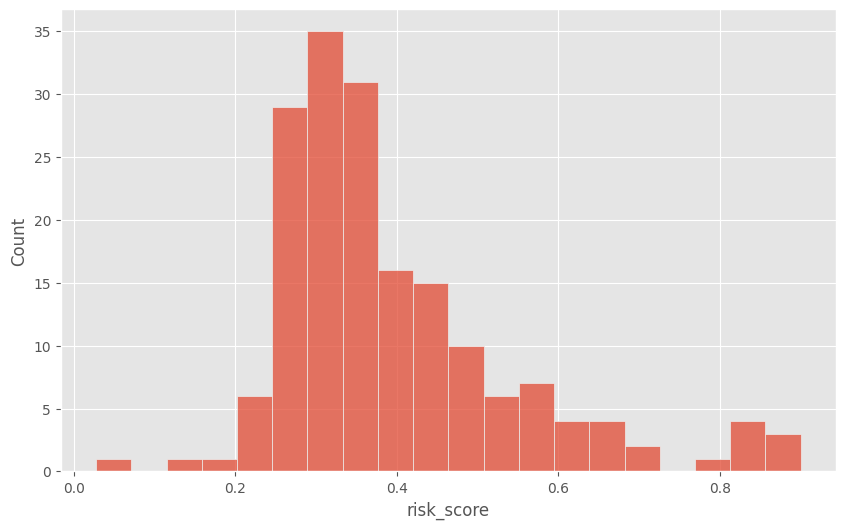

In [9]:
plt.figure(figsize=(10,6))

sns.histplot(df["risk_score"], bins=20)

plt.show()

In [10]:
df.sort_values(
    "risk_score",
    ascending=False
).head(20)

,provinsi,kabupaten_kota,kemiskinan_persen,air_bersih_persen,jumlah_faskes,kemiskinan_norm,air_norm,faskes_norm,risk_score,kategori
168,Papua Pegunungan,Nduga,32.89,32.89,8,0.753442,1.000000,0.993421,0.899732,Sangat Tinggi
172,Papua Pegunungan,Mamberamo Tengah,32.20,32.89,10,0.735849,1.000000,0.986842,0.891050,Sangat Tinggi
170,Papua Pegunungan,Lanny Jaya,31.59,32.89,11,0.720296,1.000000,0.983553,0.884006,Sangat Tinggi
174,Papua Pegunungan,Yahukimo,30.61,32.89,35,0.695309,1.000000,0.904605,0.854275,Sangat Tinggi
173,Papua Pegunungan,Yalimo,27.35,32.89,8,0.612188,1.000000,0.993421,0.843230,Sangat Tinggi
169,Papua Pegunungan,Jayawijaya,29.08,32.89,30,0.656298,1.000000,0.921053,0.842782,Sangat Tinggi
171,Papua Pegunungan,Tolikara,28.75,32.89,26,0.647884,1.000000,0.934211,0.842706,Sangat Tinggi
175,Papua Pegunungan,Pegunungan Bintang,25.87,32.89,33,0.574452,1.000000,0.911184,0.807577,Sangat Tinggi
153,Papua,Supiori,42.56,87.70,6,1.000000,0.135489,1.000000,0.697421,Sangat Tinggi
165,Papua Tengah,Intan Jaya,39.21,83.21,7,0.914584,0.206309,0.996711,0.687220,Sangat Tinggi


In [11]:
corr = df[[
    "kemiskinan_persen",
    "air_bersih_persen",
    "jumlah_faskes",
    "risk_score"
]].corr()

corr

,kemiskinan_persen,air_bersih_persen,jumlah_faskes,risk_score
kemiskinan_persen,1.000000,-0.504865,-0.392604,0.901412
air_bersih_persen,-0.504865,1.000000,0.174230,-0.805582
jumlah_faskes,-0.392604,0.174230,1.000000,-0.480786
risk_score,0.901412,-0.805582,-0.480786,1.000000


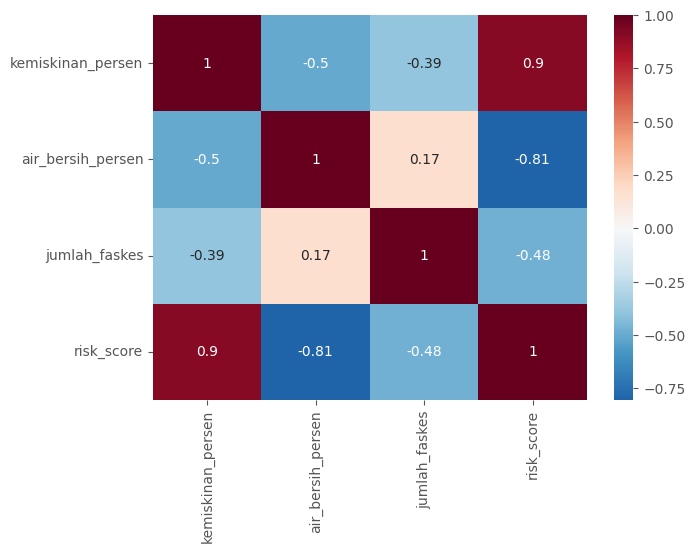

In [12]:
plt.figure(figsize=(7,5))

sns.heatmap(
    corr,
    annot=True,
    cmap="RdBu_r",
    center=0
)

plt.show()

In [ ]:
ranking = df.sort_values(
    "risk_score",
    ascending=False
)

ranking.to_excel(
    "/output/ranking_risiko_stunting.xlsx",
    index=False
)